# What Were People Actually Tweeting About in Early COVID-19?

**Question.** Given ~3,800 tweets collected in March 2020, what topics dominated the
conversation — and does the language differ between positive and negative sentiment?

**Data.** The Coronavirus Tweets NLP dataset: tweet text plus a hand-labelled sentiment
column (Extremely Negative → Extremely Positive).

**Headline result.** After stripping URLs and mentions, the conversation is overwhelmingly
about **grocery supply**: `food`, `store`, `grocery`, `supermarket`, and `panic buying`
dominate. Negative tweets skew toward panic and scarcity (`panic`, `fear`, `crisis`,
`empty`); positive tweets skew toward gratitude and small business (`thank`, `support`,
`safe`, `small business`).

**A note on preprocessing.** A naive tokenisation makes `https` the single most common
token — an artefact of URLs, not a topic. Cleaning that out is what turns the word
frequencies into something meaningful, and it's the main thing this notebook demonstrates.

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

for pkg in ["punkt", "punkt_tab", "stopwords"]:
    nltk.download(pkg, quiet=True)

df = pd.read_csv("../data/Corona_NLP_test.csv", encoding="latin1")
print(f"{len(df)} tweets, {df['TweetAt'].min()} to {df['TweetAt'].max()}")
df[["Location", "TweetAt", "OriginalTweet", "Sentiment"]].head(3)

3798 tweets, 02-03-2020 to 16-03-2020


,Location,TweetAt,OriginalTweet,Sentiment
0,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive


## 1. Sentiment breakdown

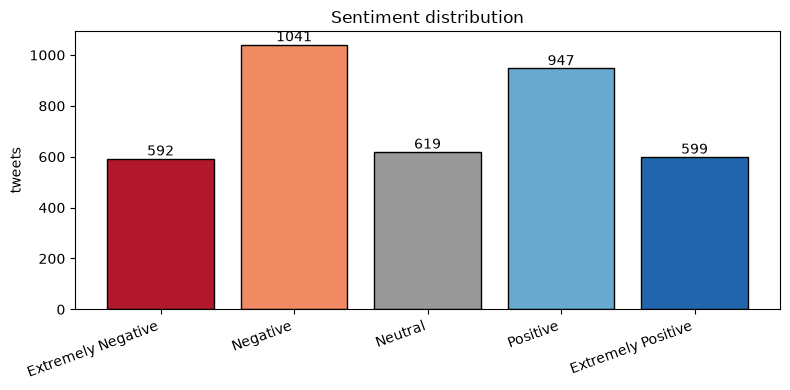

Sentiment
Extremely Negative     592
Negative              1041
Neutral                619
Positive               947
Extremely Positive     599
Name: count, dtype: int64

In [2]:
order = ["Extremely Negative", "Negative", "Neutral", "Positive", "Extremely Positive"]
counts = df["Sentiment"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#b2182b", "#ef8a62", "#999999", "#67a9cf", "#2166ac"]
ax.bar(counts.index, counts.values, color=colors, edgecolor="black")
ax.set_ylabel("tweets")
ax.set_title("Sentiment distribution")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig("../results/sentiment_distribution.png", dpi=120)
plt.show()

counts

## 2. Why raw tokenisation isn't enough

Tokenising the text as-is and removing stopwords still leaves URL fragments and Twitter
scaffolding at the top of the frequency list.

In [3]:
STOP = set(stopwords.words("english"))

def tokenize(text, clean_urls=False):
    if clean_urls:
        text = re.sub(r"http\S+|www\.\S+", " ", text)   # URLs
        text = re.sub(r"@\w+", " ", text)                # @mentions
        text = re.sub(r"&\w+;", " ", text)               # HTML entities e.g. &amp;
    tokens = nltk.word_tokenize(text.lower())
    return [t for t in tokens
            if t.isalpha() and t not in STOP and len(t) > 2]

naive = Counter()
for t in df["OriginalTweet"]:
    naive.update(tokenize(t, clean_urls=False))

pd.DataFrame(naive.most_common(10), columns=["token", "count"])

,token,count
0,https,1824
1,coronavirus,1510
2,food,1331
3,store,1012
4,grocery,816
5,people,783
6,stock,780
7,amp,610
8,shopping,522
9,supermarket,515


`https` tops the list, along with `amp` (the HTML entity for `&`). Neither is a topic —
they're noise from URLs and un-decoded markup. Now with cleaning applied:

In [4]:
freq = Counter()
for t in df["OriginalTweet"]:
    freq.update(tokenize(t, clean_urls=True))

top = pd.DataFrame(freq.most_common(20), columns=["token", "count"])
print(f"{len(freq):,} unique tokens, {sum(freq.values()):,} total")
top.head(20)

10,020 unique tokens, 64,107 total


,token,count
0,coronavirus,1510
1,food,1331
2,store,1012
3,grocery,816
4,people,783
5,stock,780
6,shopping,522
7,supermarket,515
8,online,509
9,panic,483


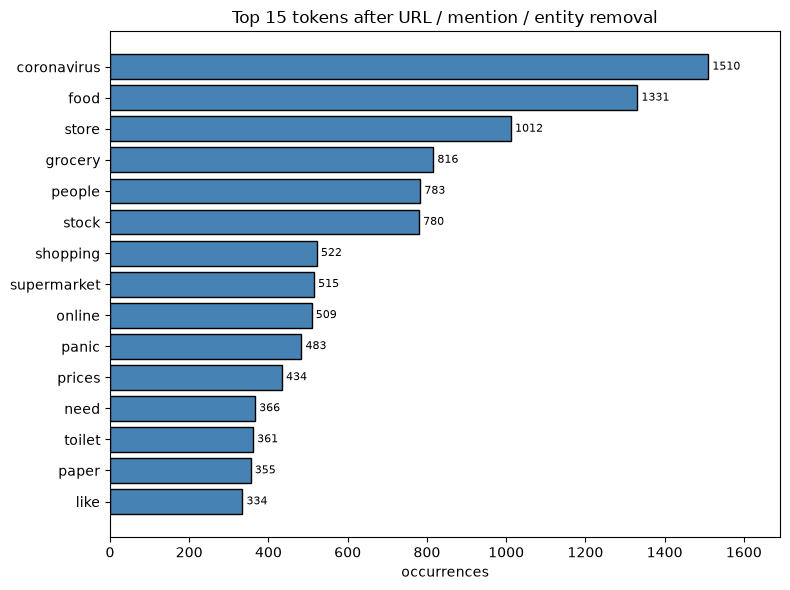

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
head = top.head(15).iloc[::-1]
ax.barh(head["token"], head["count"], color="steelblue", edgecolor="black")
ax.set_xlabel("occurrences")
ax.set_title("Top 15 tokens after URL / mention / entity removal")
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
ax.margins(x=0.12)
fig.tight_layout()
fig.savefig("../results/top_tokens.png", dpi=120)
plt.show()

## 3. Word cloud

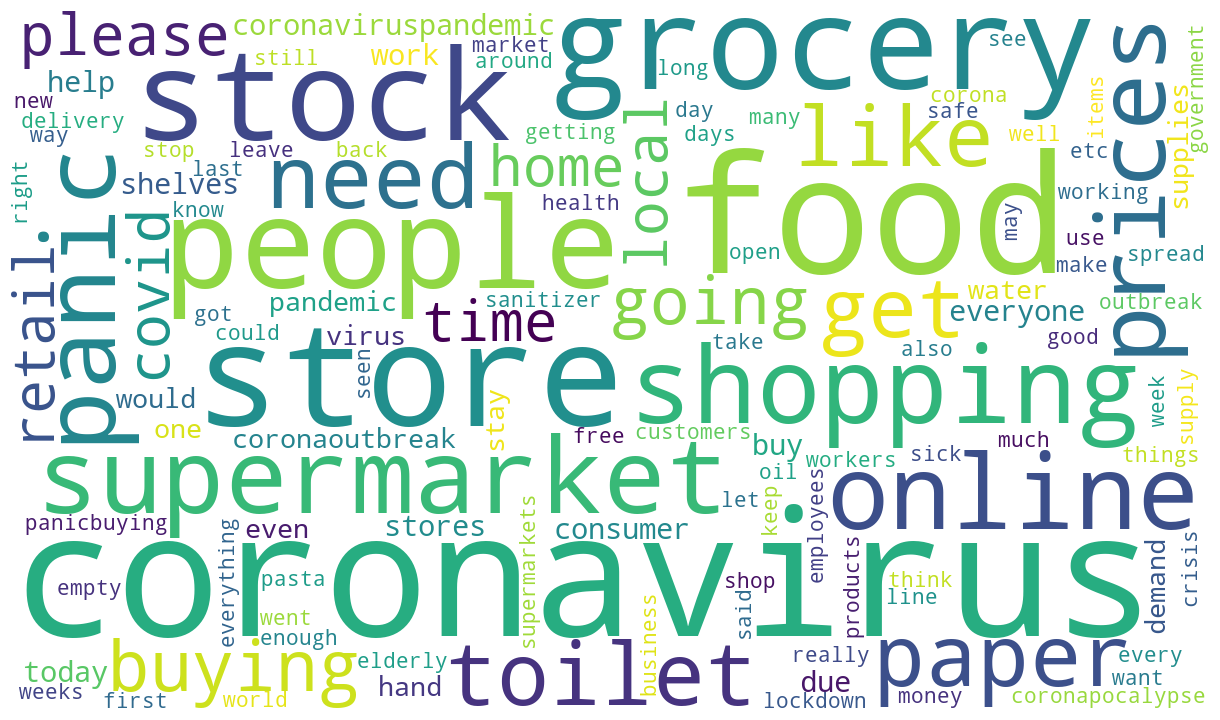

In [6]:
wc = WordCloud(width=1200, height=700, background_color="white",
               max_words=120, colormap="viridis").generate_from_frequencies(freq)

fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
fig.tight_layout(pad=0)
fig.savefig("../results/wordcloud.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Does the language differ by sentiment?

Comparing the most distinctive words in negative vs. positive tweets says more than a
single global frequency list. Two details matter for this to be meaningful: rates are
computed *within* each class so the comparison isn't skewed by one class having more
tweets, and only tokens appearing at least 40 times overall are scored — otherwise rare
words produce enormous ratios that look like findings but are noise.

In [7]:
def class_counts(sentiments):
    c = Counter()
    for t in df.loc[df["Sentiment"].isin(sentiments), "OriginalTweet"]:
        c.update(tokenize(t, clean_urls=True))
    return c

neg = class_counts(["Negative", "Extremely Negative"])
pos = class_counts(["Positive", "Extremely Positive"])

comp = pd.DataFrame({"neg": pd.Series(neg), "pos": pd.Series(pos)}).fillna(0)

# Only judge words common enough for the comparison to mean anything.
MIN_TOTAL = 40
comp = comp[(comp["neg"] + comp["pos"]) >= MIN_TOTAL]

# Convert to within-class rates so the two classes are comparable in size,
# then take a smoothed log ratio. Positive score = more negative-leaning.
comp["neg_rate"] = comp["neg"] / comp["neg"].sum()
comp["pos_rate"] = comp["pos"] / comp["pos"].sum()
alpha = 1e-5
comp["log_ratio"] = np.log2((comp["neg_rate"] + alpha) / (comp["pos_rate"] + alpha))

cols = ["neg", "pos", "log_ratio"]
print(f"{len(comp)} tokens with >= {MIN_TOTAL} total occurrences\n")
print("More characteristic of NEGATIVE tweets:")
display(comp.nlargest(10, "log_ratio")[cols].round(2))
print("More characteristic of POSITIVE tweets:")
display(comp.nsmallest(10, "log_ratio")[cols].round(2))

230 tokens with >= 40 total occurrences

More characteristic of NEGATIVE tweets:


,neg,pos,log_ratio
sick,78.0,16.0,2.23
paid,50.0,11.0,2.12
crisis,59.0,13.0,2.12
fear,40.0,9.0,2.09
stop,79.0,19.0,2.00
emergency,33.0,8.0,1.98
panic,352.0,111.0,1.61
left,35.0,11.0,1.61
empty,96.0,34.0,1.44
media,31.0,11.0,1.43


More characteristic of POSITIVE tweets:


,neg,pos,log_ratio
thank,5.0,51.0,-3.37
support,6.0,48.0,-3.02
best,6.0,43.0,-2.86
safe,10.0,69.0,-2.82
great,7.0,43.0,-2.65
small,7.0,35.0,-2.35
business,12.0,49.0,-2.07
good,24.0,89.0,-1.94
hand,29.0,107.0,-1.93
help,43.0,137.0,-1.72


## Findings

1. **Groceries, not medicine, dominated the early conversation.** After `coronavirus`
   itself, the eight most frequent tokens include `food` (1,331), `store` (1,012),
   `grocery` (816), `shopping` (522), and `supermarket` (515), with `panic`, `prices`,
   and `toilet paper` close behind. The March 2020 discourse in this sample is about
   supply, not symptoms.
2. **Preprocessing changed the answer.** Without URL and entity stripping, the two most
   frequent tokens are `https` and `amp` — pure noise that would have been reported as
   findings. This is the single highest-leverage step in the pipeline.
3. **Sentiment splits along panic vs. solidarity.** Negative tweets over-index on
   `sick`, `crisis`, `fear`, `panic`, and `empty` — the language of shortage and alarm.
   Positive tweets over-index on `thank`, `support`, `safe`, and `small business` — the
   language of community response. The split is emotional register, not subject matter:
   both classes are talking about the same shops.

### Limitations
- This is the ~3.8k-row test split, not the full ~44k dataset — frequencies are indicative,
  not definitive.
- Sentiment labels are pre-assigned in the dataset; this notebook analyses them rather
  than validating or reproducing them.
- Frequency analysis finds topics, not stance. A word appearing in negative tweets doesn't
  mean the word is negative.

### Outputs
`results/sentiment_distribution.png`, `results/top_tokens.png`, `results/wordcloud.png`